In [1]:
# Import necessary libraries and suppress warnings
import warnings
warnings.filterwarnings('ignore')

import pandas                  as pd
import numpy                   as np
import matplotlib.pyplot       as plt
import seaborn                 as sns
import statsmodels.api         as sm
import statsmodels.formula.api as smf

# This statement allow to display plot without asking to 
%matplotlib inline

# always make it pretty 
plt.style.use('ggplot')

In [2]:
df = pd.read_csv("Data_MLB_2025_StatcastPostseason_PitchByPitch_20251102a.csv")

print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(list(df.columns))

Rows: 14096, Columns: 95
['game_year', 'game_date', 'player_name', 'pitcher', 'batter', 'balls', 'strikes', 'inning', 'inning_topbot', 'at_bat_number', 'pitch_number', 'events', 'pitch_type', 'pitch_name', 'release_speed', 'release_pos_x', 'release_pos_z', 'description', 'spin_dir', 'spin_rate_deprecated', 'break_angle_deprecated', 'break_length_deprecated', 'zone', 'des', 'game_type', 'stand', 'p_throws', 'home_team', 'away_team', 'type', 'hit_location', 'bb_type', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'on_3b', 'on_2b', 'on_1b', 'outs_when_up', 'hc_x', 'hc_y', 'tfs_deprecated', 'tfs_zulu_deprecated', 'fielder_2', 'fielder_2.1', 'umpire', 'sv_id', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az', 'sz_top', 'sz_bot', 'hit_distance_sc', 'launch_speed', 'launch_angle', 'effective_speed', 'release_spin_rate', 'release_extension', 'game_pk', 'fielder_2.2', 'fielder_2.3', 'fielder_3', 'fielder_4', 'fielder_5', 'fielder_6', 'fielder_7', 'fielder_8', 'fielder_9', 'release_pos_y', 'estimated_ba_using_sp

The following are the columns of the dataset.

**game_year**: Year it took place

**game_date**: Date of the game

**pitch_type**: The type of pitch derived from Statcast

**events**: Event of the resulting plate appearance

**description**: Description of the resulting pitch

**launch_speed**: Exit velocity of the batted ball as tracked by Statcast. For batted balls not tracked directly, estimates are included based on Statcast's estimation process

**pitch_name**: The name of the pitch derived from the Statcast data

**home_score**: Pre-pitch home team score

**away_score**: Pre-pitch away team score

**bat_score**: Pre-pitch batting team score

**fld_score**: Pre-pitch fielding team score

**if_fielding_alignment**: Infield fielding alignment at the time of the pitch

**of_fielding_alignment**: Outfield fielding alignment at the time of the pitch

**spin_axis**: Spin axis in the 2D X–Z plane in degrees from 0–360 (180 represents pure backspin, 0 represents pure topspin)

**effective_speed**: Derived speed based on the extension of the pitcher's release

**release_spin_rate**: Release spin rate (TBD in original source)

**release_extension**: Release extension of pitch in feet as tracked by Statcast

**release_pos_y**: Release position of pitch measured in feet from the catcher's perspective

**at_bat_number**: Plate appearance number within the game

**player_name**: Player's name tied to the event

**batter**: MLB player ID for the batter tied to the play event

**pitcher**: MLB player ID for the pitcher tied to the play event

**pfx_x**: Horizontal movement in feet from the catcher's perspective

**release_speed**: Pitch velocity. Velocities from 2008–16 are via Pitch F/X (adjusted); velocities from 2017 onward are Statcast out-of-hand measurements

**release_pos_x**: Horizontal release position in feet from the catcher's perspective

**release_pos_z**: Vertical release position in feet from the catcher's perspective

**spin_dir**: Deprecated field from the older tracking system

**zone**: Zone location of the ball when it crosses the plate from the catcher's perspective

**p_throws**: Hand the pitcher throws with

**stand**: Batter's side of the plate (left/right)

**balls**: Pre-pitch number of balls in the count

**strikes**: Pre-pitch number of strikes in the count

**pfx_z**: Vertical movement in feet from the catcher's perspective

**plate_x**: Horizontal position of the ball as it crosses home plate from the catcher's perspective

**plate_z**: Vertical position of the ball as it crosses home plate from the catcher's perspective

**vx0**: Velocity of the pitch in x-dimension (ft/s), determined at y=50 ft

**vy0**: Velocity of the pitch in y-dimension (ft/s), determined at y=50 ft

**vz0**: Velocity of the pitch in z-dimension (ft/s), determined at y=50 ft

**ax**: Acceleration in x-dimension (ft/s^2), determined at y=50 ft

**ay**: Acceleration in y-dimension (ft/s^2), determined at y=50 ft

**az**: Acceleration in z-dimension (ft/s^2), determined at y=50 ft

## Data Types & Duplicates

In [5]:
print("Data types:")
print(df.dtypes.value_counts().to_string())
print(f"Exact duplicate rows: {df.duplicated().sum()}")
print(f"game_date dtype: {df['game_date'].dtype} - needs parsing to datetime")

Data types:
float64    48
int64      30
object     17
Exact duplicate rows: 0
game_date dtype: object - needs parsing to datetime


In [6]:
cols_dropped = list(df.columns[df.isna().all()])
print(f'Columns to drop: \n{list(df.columns[df.isna().all()])}')

df.drop(columns=cols_dropped, inplace=True)


Columns to drop: 
['spin_dir', 'spin_rate_deprecated', 'break_angle_deprecated', 'break_length_deprecated', 'tfs_deprecated', 'tfs_zulu_deprecated', 'umpire', 'sv_id']


## Filter to Blue Jays Pitching Only

When Toronto is the **home** team, their pitchers throw in the **Top** of the inning. When Toronto is the **away** team, their pitchers throw in the **Bot** of the inning.

In [8]:
bj_df = df[
    ((df["home_team"] == "TOR") & (df["inning_topbot"] == "Top")) |
    ((df["away_team"] == "TOR") & (df["inning_topbot"] == "Bot"))
]

#This line passes variables across notebooks
%store bj_df

print(f"Blue Jays pitching rows: {bj_df.shape[0]:}")
print(f"Unique games: {bj_df['game_pk'].nunique()}")
print(f"Unique pitchers (by ID): {bj_df['pitcher'].nunique()}")


Stored 'bj_df' (DataFrame)
Blue Jays pitching rows: 2788
Unique games: 18
Unique pitchers (by ID): 15


## Missing Values — Blue Jays Pitching Subset

In [10]:
null = bj_df.isnull().sum()
null_percent = (bj_df.isnull().sum() / len(bj_df) * 100).round(2)
null_df = pd.DataFrame({"missing_count": null, "missing_percent": null_percent})
null_df = null_df[null_df["missing_count"] > 0].sort_values("missing_percent", ascending=False)
print(f"Columns with missing values: {len(null_df)} out of {bj_df.shape[1]}\n")
null_df

Columns with missing values: 20 out of 87



,missing_count,missing_percent
on_3b,2599,93.22
launch_speed_angle,2340,83.93
estimated_ba_using_speedangle,2340,83.93
bb_type,2337,83.82
hc_x,2337,83.82
hc_y,2337,83.82
on_2b,2315,83.03
hit_location,2188,78.48
estimated_woba_using_speedangle,2092,75.04
woba_denom,2090,74.96


## Build an Analysis-Ready Blue Jays Pitching Dataset

Turn `bj_df` into a cleaned dataframe that is easier to use for EDA and modeling. In this section we:

1. parse dates and sort the data chronologically,
2. classify missing values based on baseball context,
3. keep the columns that are most useful for our research questions, and
4. create helper variables that will be reused in later notebooks.

This is important because many missing values in Statcast are **structural** rather than data errors.

In [12]:
# Step 1: Parse dates and sort the Blue Jays pitching subset in game order.
#
# Why this block exists:
# - `game_date` was read in as text, but we will want it as a real datetime.
# - Chronological sorting makes later trend analysis and lag-feature work safer.

bj_df = bj_df.copy()
bj_df["game_date"] = pd.to_datetime(bj_df["game_date"])

sort_cols = [col for col in ["game_date", "game_pk", "at_bat_number", "pitch_number"] if col in bj_df.columns]
bj_df = bj_df.sort_values(sort_cols).reset_index(drop=True)

print(f"Date range: {bj_df['game_date'].min().date()} to {bj_df['game_date'].max().date()}")
print(f"Rows after sorting: {len(bj_df)}")
print(f"Duplicate rows after preprocessing: {bj_df.duplicated().sum()}")

Date range: 2025-10-04 to 2025-11-01
Rows after sorting: 2788
Duplicate rows after preprocessing: 0


## Create a Cleaner Analysis Table

This block keeps the variables that are most useful for Blue Jays pitching analysis and creates a few helper features.

The helper features are designed to support both of your downstream directions:

- performance analysis, such as strike rate and whiff rate,
- pitch-sequencing or pitch-type prediction, where count, previous context, and base state matter.

We also simplify the raw ball-strike count into a more baseball-oriented representation:

- `count_leverage`: whether the count favors the pitcher, favors the hitter, or is even,
- `has_two_strikes`: whether the batter already has two strikes.

This makes the count easier to interpret in plots and summaries while still preserving one of the most important strategic situations in baseball: the two-strike count.

We are not imputing everything here. Instead, we keep a compact, analysis-ready dataset and leave specialized treatment for later notebooks if needed.

In [14]:
# Keep core variables 

# - smaller dataframe focused on pitch context, pitcher identity,
#   count state, and key Statcast movement / command variables.
# - adds binary indicators that will be reused in later EDA and models.

core_columns = [
    "game_date", "game_pk", "inning", "inning_topbot", "at_bat_number", "pitch_number",
    "pitcher", "player_name", "stand", "p_throws",
    "balls", "strikes", "outs_when_up",
    "home_team", "away_team", "bat_score", "fld_score",
    "pitch_type", "pitch_name", "release_speed", "release_spin_rate",
    "release_pos_x", "release_pos_z", "pfx_x", "pfx_z", "plate_x", "plate_z",
    "zone", "description", "type", "events",
    "if_fielding_alignment", "of_fielding_alignment",
    "on_1b", "on_2b", "on_3b"
]

available_core_columns = [col for col in core_columns if col in bj_df.columns]
bj_clean = bj_df[available_core_columns].copy()

# Count state combines balls and strikes into one game-context variable.
bj_clean["count_state"] = bj_clean["balls"].astype(str) + "-" + bj_clean["strikes"].astype(str)

# We keep the raw count, but also create a simpler count category that is easier
# to analyze and explain in visuals.
#
# pitcher_ahead: the pitcher has more leverage in the count
# hitter_ahead: the hitter has more leverage in the count
# even: the count is neutral
bj_clean["count_leverage"] = np.select(
    [
        bj_clean["balls"] > bj_clean["strikes"],
        bj_clean["balls"] < bj_clean["strikes"],
        bj_clean["balls"] == bj_clean["strikes"]
    ],
    ["hitter_ahead", "pitcher_ahead", "even"],
    default="other"
)

# Two-strike counts often change pitch selection and pitcher intent, so we keep
# that situation as a separate binary feature.
bj_clean["has_two_strikes"] = bj_clean["strikes"].eq(2).astype(int)

# Score differential is from Toronto's pitching perspective.
bj_clean["score_diff"] = bj_clean["fld_score"] - bj_clean["bat_score"]

# Binary pitch outcome flags
bj_clean["is_strike"] = bj_clean["type"].eq("S").astype(int)
bj_clean["is_whiff"] = bj_clean["description"].isin(["swinging_strike", "swinging_strike_blocked"]).astype(int)
bj_clean["is_in_play"] = bj_clean["description"].eq("hit_into_play").astype(int)

# Base-state helper features make runner context easier to analyze.
base_cols = [col for col in ["on_1b", "on_2b", "on_3b"] if col in bj_clean.columns]
bj_clean["men_on_base"] = bj_clean[base_cols].notna().sum(axis=1)
bj_clean["runners_in_scoring_position"] = bj_clean[[col for col in ["on_2b", "on_3b"] if col in bj_clean.columns]].notna().any(axis=1).astype(int)

# A quick missing-value check on the cleaned table helps us see whether any core fields still need attention.
core_missing = bj_clean.isnull().mean().mul(100).round(2).sort_values(ascending=False)
core_missing = core_missing[core_missing > 0]

print(f"Cleaned dataframe shape: {bj_clean.shape}")
print(f"Columns retained: {len(available_core_columns)} original columns + engineered features")
print("\nCount leverage breakdown:")
print(bj_clean["count_leverage"].value_counts().to_string())
print(f"\nTwo-strike pitches: {bj_clean['has_two_strikes'].sum()} ({bj_clean['has_two_strikes'].mean() * 100:.2f}%)")
print("\nMissingness in cleaned dataframe (non-zero only):")
print(core_missing.to_string() if len(core_missing) else "No missing values remain in the cleaned table.")

# Store the cleaned dataframe so later notebooks can import the same analysis-ready version.
%store bj_clean

bj_clean.head()

Cleaned dataframe shape: (2788, 45)
Columns retained: 36 original columns + engineered features

Count leverage breakdown:
count_leverage
even             1253
pitcher_ahead     786
hitter_ahead      749

Two-strike pitches: 819 (29.38%)

Missingness in cleaned dataframe (non-zero only):
on_3b     93.22
on_2b     83.03
events    74.86
on_1b     68.26
Stored 'bj_clean' (DataFrame)


,game_date,game_pk,inning,inning_topbot,at_bat_number,pitch_number,pitcher,player_name,stand,p_throws,...,on_3b,count_state,count_leverage,has_two_strikes,score_diff,is_strike,is_whiff,is_in_play,men_on_base,runners_in_scoring_position
0,2025-10-04,813063,1,Top,1,1,592332,"Gausman, Kevin",L,R,...,NaN,0-0,even,0,0,0,0,1,0,0
1,2025-10-04,813063,1,Top,2,1,592332,"Gausman, Kevin",R,R,...,NaN,0-0,even,0,0,1,0,0,0,0
2,2025-10-04,813063,1,Top,2,2,592332,"Gausman, Kevin",R,R,...,NaN,0-1,pitcher_ahead,0,0,0,0,1,0,0
3,2025-10-04,813063,1,Top,3,1,592332,"Gausman, Kevin",L,R,...,NaN,0-0,even,0,0,1,1,0,1,0
4,2025-10-04,813063,1,Top,3,2,592332,"Gausman, Kevin",L,R,...,NaN,0-1,pitcher_ahead,0,0,0,0,0,1,0


## Output of Section

2 dataframes:

- `bj_df`: the full Blue Jays pitching subset after basic filtering,
- `bj_clean`: a smaller, analysis-ready version with reusable helper features.


### Summary of Findings

- The Blue Jays pitching subset contains **2,788 pitches** across **18 games** from **15 pitchers**, which is enough for section-level EDA but still small enough that very narrow splits should be interpreted carefully.
- There are **20 columns with missing values out of 87**, but the largest gaps are mostly structural baseball-related nulls rather than obvious data-quality problems. For example, `on_3b` is missing **93.22%** of the time and `on_2b` is missing **83.03%** of the time because those bases are usually empty.
- The simplified count feature is reasonably balanced: **1,253 even counts**, **786 pitcher-ahead counts**, and **749 hitter-ahead counts**. That makes `count_leverage` useful for later comparisons.
- About **29.38%** of pitches came in two-strike counts, and runners were in scoring position on **19.87%** of pitches. Those context features should be helpful in the later performance sections.

## Exploratory Data Analysis

Now that the data is cleaned, we can move into a small EDA section. The goal here is to keep things simple and answer a few high-value questions:

1. What pitches do Blue Jays pitchers throw most often?
2. How do strike, whiff, and in-play rates change with count situation?
3. Which pitchers handled the largest workloads, and how did they perform at a high level?
4. Do velocity and whiff rate change over the course of a game?

These summaries give us an overview of usage, effectiveness, and context before we do any more specialized analysis.

### Pitch Mix Overview

This block summarizes the most frequently used pitch types and visualizes the overall pitch mix. It tells us which pitch types drive the staff's identity and which ones are used more selectively.

,pitch_name,count,percent
0,4-Seam Fastball,937,33.6
1,Slider,540,19.4
2,Split-Finger,402,14.4
3,Cutter,196,7.0
4,Knuckle Curve,174,6.2
5,Sinker,145,5.2
6,Curveball,136,4.9
7,Sweeper,131,4.7
8,Changeup,127,4.6


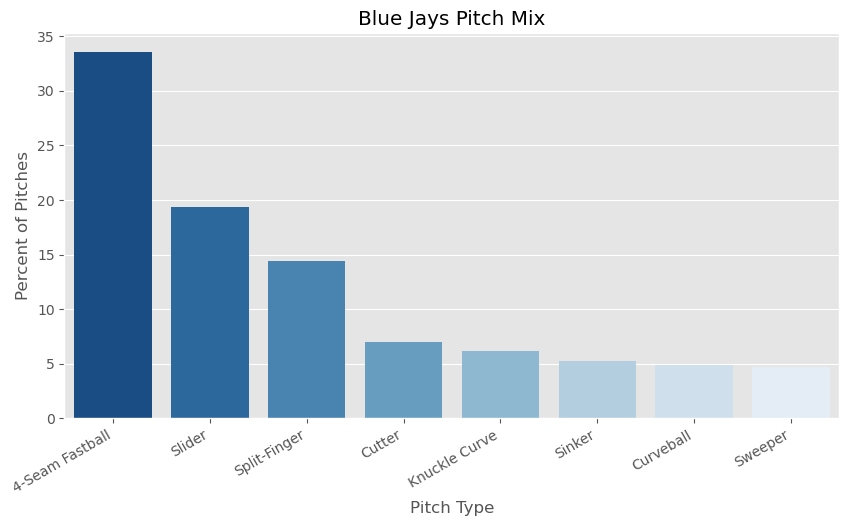

In [19]:
# EDA Block 1: Summarize the overall pitch mix.

pitch_mix = (
    bj_clean["pitch_name"]
    .value_counts()
    .rename_axis("pitch_name")
    .reset_index(name="count")
)
pitch_mix["percent"] = (pitch_mix["count"] / pitch_mix["count"].sum() * 100).round(1)

display(pitch_mix.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data=pitch_mix.head(8), x="pitch_name", y="percent", palette="Blues_r")
plt.title("Blue Jays Pitch Mix")
plt.xlabel("Pitch Type")
plt.ylabel("Percent of Pitches")
plt.xticks(rotation=30, ha="right")
plt.show()

### Outcomes by Count Situation

This block compares strike rate, whiff rate, and in-play rate across the simplified count features we created earlier. It helps show how pitching outcomes change when the pitcher is ahead, behind, or working with two strikes.

,is_strike,is_whiff,is_in_play
count_leverage,,,
even,0.495,0.120,0.150
hitter_ahead,0.505,0.117,0.170
pitcher_ahead,0.368,0.165,0.173


,is_strike,is_whiff,is_in_play
has_two_strikes,,,
0,0.483,0.119,0.143
1,0.410,0.164,0.208


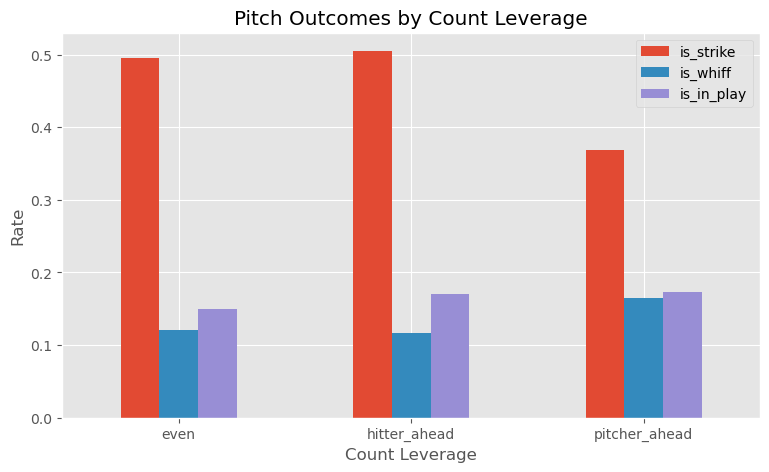

In [21]:
# EDA Block 2: Compare outcomes across count situations.

count_summary = (
    bj_clean
    .groupby("count_leverage")[["is_strike", "is_whiff", "is_in_play"]]
    .mean()
    .round(3)
    .sort_index()
)

two_strike_summary = (
    bj_clean
    .groupby("has_two_strikes")[["is_strike", "is_whiff", "is_in_play"]]
    .mean()
    .round(3)
)

display(count_summary)
display(two_strike_summary)

count_summary.plot(kind="bar", figsize=(9, 5))
plt.title("Pitch Outcomes by Count Leverage")
plt.xlabel("Count Leverage")
plt.ylabel("Rate")
plt.xticks(rotation=0)
plt.legend(loc="best")
plt.show()

### High-Level Pitcher Summary

This block identifies the pitchers who threw the most pitches and summarizes a few simple performance indicators. This is useful for seeing which pitchers are most influential in the dataset and whether usage and effectiveness vary across arms.

,pitches,avg_velocity,strike_rate,whiff_rate
player_name,,,,
"Yesavage, Trey",440,89.151,0.495,0.168
"Gausman, Kevin",436,89.288,0.463,0.156
"Bieber, Shane",310,87.923,0.439,0.113
"Varland, Louis",250,93.939,0.448,0.128
"Scherzer, Max",220,89.029,0.464,0.123
"Hoffman, Jeff",207,90.855,0.498,0.155
"Domínguez, Seranthony",199,93.097,0.387,0.121
"Fluharty, Mason",138,86.644,0.514,0.145
"Lauer, Eric",136,86.903,0.478,0.066


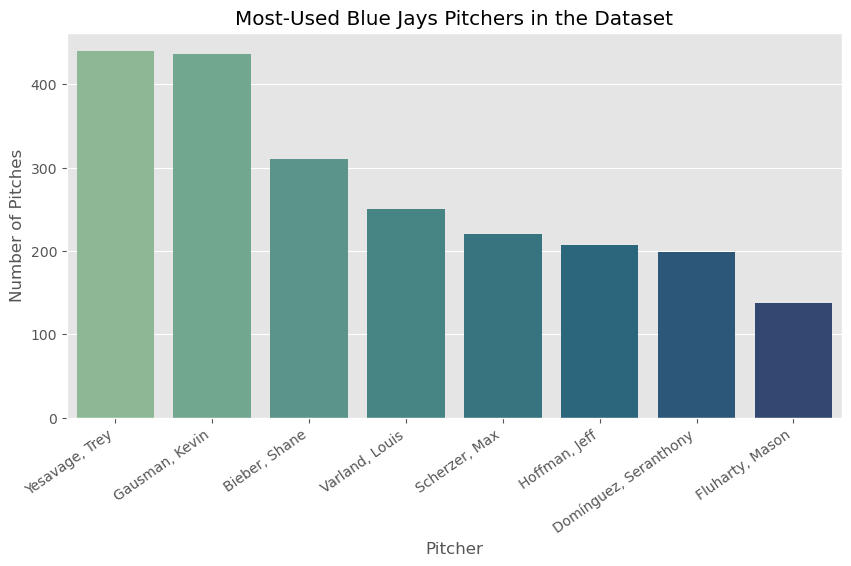

In [23]:
# EDA Block 3: Summarize the most-used pitchers.

pitcher_summary = (
    bj_clean
    .groupby("player_name")
    .agg(
        pitches=("pitch_name", "size"),
        avg_velocity=("release_speed", "mean"),
        strike_rate=("is_strike", "mean"),
        whiff_rate=("is_whiff", "mean")
    )
    .sort_values("pitches", ascending=False)
    .round(3)
)

display(pitcher_summary.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data=pitcher_summary.head(8).reset_index(), x="player_name", y="pitches", palette="crest")
plt.title("Most-Used Blue Jays Pitchers in the Dataset")
plt.xlabel("Pitcher")
plt.ylabel("Number of Pitches")
plt.xticks(rotation=35, ha="right")
plt.show()

### Inning-Level Trends

This final EDA block checks whether average velocity and whiff rate change by inning. It gives us a simple first look at whether pitcher effectiveness appears to change as games progress.

,release_speed,is_whiff,is_strike
inning,,,
1,89.710,0.140,0.465
2,89.390,0.179,0.525
3,88.812,0.142,0.452
4,88.797,0.155,0.477
5,88.940,0.119,0.484
6,89.261,0.138,0.441
7,90.716,0.088,0.424
8,90.203,0.111,0.443
9,90.791,0.143,0.479


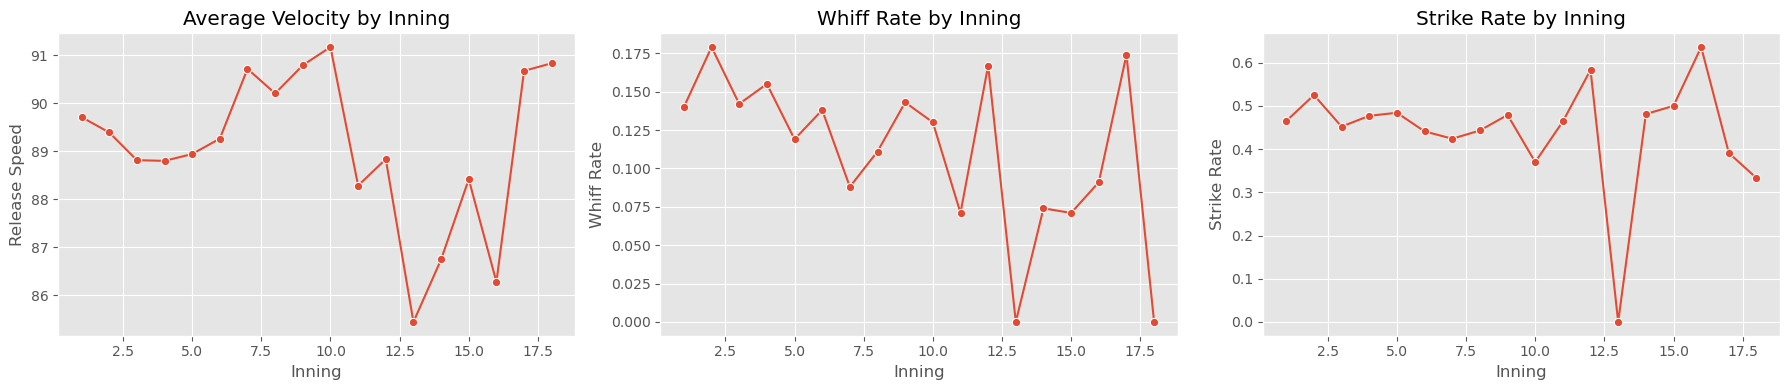

In [25]:
# EDA Block 4: Look for inning-level changes in velocity, whiff rate, and strike rate.

inning_summary = (
    bj_clean
    .groupby("inning")[["release_speed", "is_whiff", "is_strike"]]
    .mean()
    .round(3)
)

display(inning_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.lineplot(data=inning_summary, x=inning_summary.index, y="release_speed", marker="o", ax=axes[0])
axes[0].set_title("Average Velocity by Inning")
axes[0].set_xlabel("Inning")
axes[0].set_ylabel("Release Speed")

sns.lineplot(data=inning_summary, x=inning_summary.index, y="is_whiff", marker="o", ax=axes[1])
axes[1].set_title("Whiff Rate by Inning")
axes[1].set_xlabel("Inning")
axes[1].set_ylabel("Whiff Rate")

sns.lineplot(data=inning_summary, x=inning_summary.index, y="is_strike", marker="o", ax=axes[2])
axes[2].set_title("Strike Rate by Inning")
axes[2].set_xlabel("Inning")
axes[2].set_ylabel("Strike Rate")

plt.tight_layout()
plt.show()

### Investigate why whiff and strike rate drop to 0 at around inning 13
Since a baseball game last 9 innings. Any inning past 9 are extra innings. This could suggest that it is a small sample size

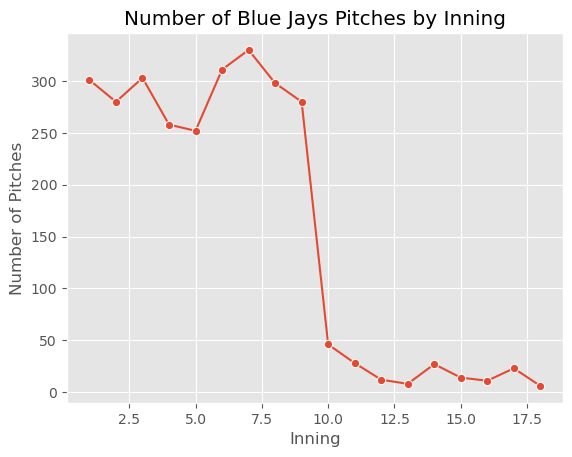

,inning,pitch_count
0,1,301
1,2,280
2,3,303
3,4,258
4,5,252
5,6,311
6,7,330
7,8,298
8,9,280
9,10,46


In [27]:
# Count how many Blue Jays pitches were thrown in extra innings
extra_inning_counts = (
    bj_clean
    .groupby("inning")
    .size()
    .reset_index(name="pitch_count")
)

extra_inning_counts

sns.lineplot(data=extra_inning_counts, x="inning", y="pitch_count", marker="o")
plt.title("Number of Blue Jays Pitches by Inning")  
plt.xlabel("Inning")
plt.ylabel("Number of Pitches")
plt.show()
extra_inning_counts


The number of pitches thrown drops off significantly after the 9th inning. For future progression analysis, we may have to omit the extra innings or keep in mind the drop in sample size in mind during interpretation

### Summary of Findings

- The overall pitch mix is led by the **4-Seam Fastball (33.6%)**, followed by the **Slider (19.4%)** and **Split-Finger (14.4%)**. That suggests the staff relies heavily on fastball-slider/split combinations.
- Count situation matters. In pitcher-ahead counts, the Blue Jays produced their best whiff rate at **0.165**, compared with **0.120** in even counts and **0.117** in hitter-ahead counts. That supports keeping the count-based features in the analysis.
- The heaviest workloads came from **Yesavage, Trey (440 pitches)** and **Gausman, Kevin (436 pitches)**. Among the most-used pitchers, Yesavage posted a **0.168 whiff rate**, while Hoffman combined a **0.498 strike rate** with a **90.855 mph** average release speed.
- Across innings 1 to 9, velocity was fairly stable, ranging from **88.797 mph** in the 4th inning to **90.791 mph** in the 9th. Whiff rate was highest in the **2nd inning (0.179)** and lowest in the **7th inning (0.088)**, but those inning-level shifts should still be treated as descriptive rather than definitive.

## EDA continued: Pitch Type
- velocity by pitch type
- whiff rate by pitch type
- is_strike by pitch type
- is_in_play by pitch type
- count leverage by pitch type
- pitch usage by inning

This section keeps the pitch-type analysis simple. Each block below includes a small table and a graph so we can compare pitch types quickly and clearly.

In [31]:
# Build one summary table for pitch type.

pitch_type_summary = (
    bj_clean
    .groupby("pitch_name")
    .agg(
        pitches=("pitch_name", "size"),
        avg_velocity=("release_speed", "mean"),
        whiff_rate=("is_whiff", "mean"),
        strike_rate=("is_strike", "mean"),
        in_play_rate=("is_in_play", "mean")
    )
    .sort_values("pitches", ascending=False)
    .round(3)
)

display(pitch_type_summary)


,pitches,avg_velocity,whiff_rate,strike_rate,in_play_rate
pitch_name,,,,,
4-Seam Fastball,937,95.036,0.065,0.474,0.193
Slider,540,87.294,0.185,0.476,0.143
Split-Finger,402,85.098,0.231,0.438,0.129
Cutter,196,90.218,0.107,0.444,0.168
Knuckle Curve,174,86.620,0.172,0.466,0.121
Sinker,145,94.477,0.069,0.441,0.200
Curveball,136,79.221,0.125,0.529,0.147
Sweeper,131,82.515,0.176,0.473,0.099
Changeup,127,89.786,0.102,0.346,0.197


,pitches,avg_velocity
pitch_name,,
4-Seam Fastball,937,95.036
Sinker,145,94.477
Cutter,196,90.218
Changeup,127,89.786
Slider,540,87.294
Knuckle Curve,174,86.620
Split-Finger,402,85.098
Sweeper,131,82.515
Curveball,136,79.221


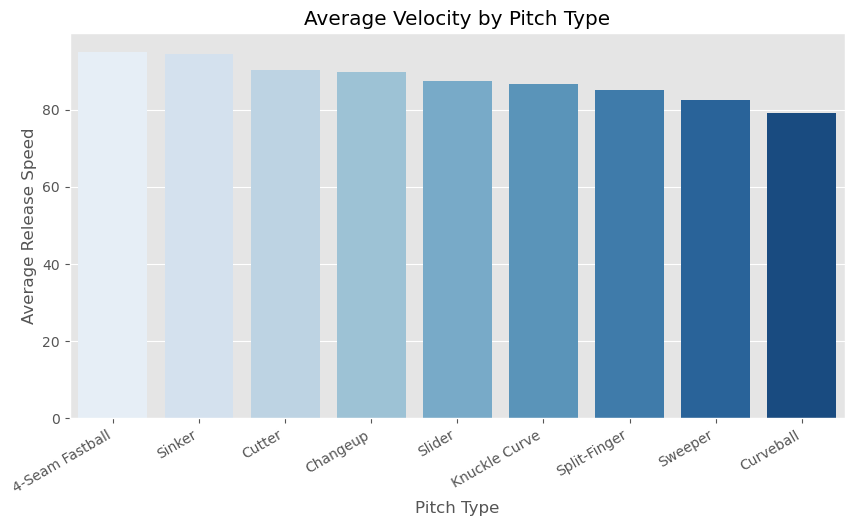

In [32]:
# Velocity by pitch type: table and graph.

velocity_table = pitch_type_summary[["pitches", "avg_velocity"]].sort_values("avg_velocity", ascending=False)
display(velocity_table)

plt.figure(figsize=(10, 5))
sns.barplot(data=velocity_table.reset_index(), x="pitch_name", y="avg_velocity", palette="Blues")
plt.title("Average Velocity by Pitch Type")
plt.xlabel("Pitch Type")
plt.ylabel("Average Release Speed")
plt.xticks(rotation=30, ha="right")
plt.show()


,pitches,whiff_rate
pitch_name,,
Split-Finger,402,0.231
Slider,540,0.185
Sweeper,131,0.176
Knuckle Curve,174,0.172
Curveball,136,0.125
Cutter,196,0.107
Changeup,127,0.102
Sinker,145,0.069
4-Seam Fastball,937,0.065


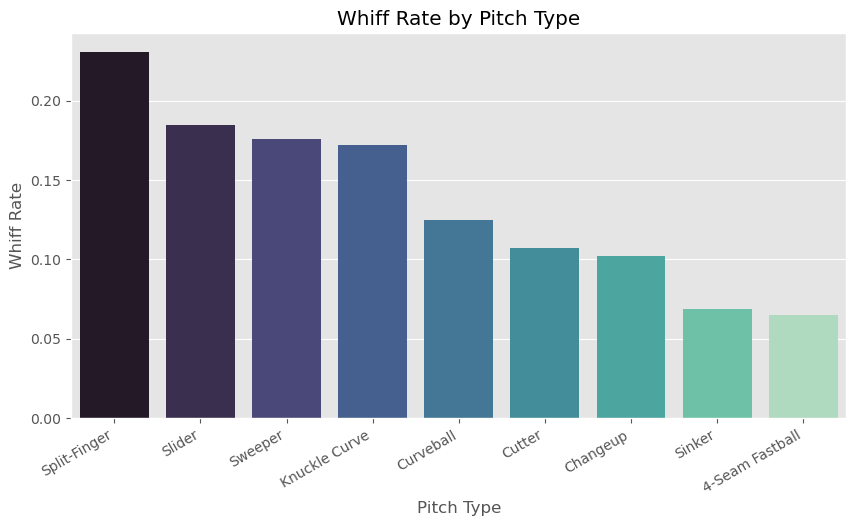

In [33]:
# Whiff rate by pitch type: table and graph.

whiff_table = pitch_type_summary[["pitches", "whiff_rate"]].sort_values("whiff_rate", ascending=False)
display(whiff_table)

plt.figure(figsize=(10, 5))
sns.barplot(data=whiff_table.reset_index(), x="pitch_name", y="whiff_rate", palette="mako")
plt.title("Whiff Rate by Pitch Type")
plt.xlabel("Pitch Type")
plt.ylabel("Whiff Rate")
plt.xticks(rotation=30, ha="right")
plt.show()


,pitches,strike_rate
pitch_name,,
Curveball,136,0.529
Slider,540,0.476
4-Seam Fastball,937,0.474
Sweeper,131,0.473
Knuckle Curve,174,0.466
Cutter,196,0.444
Sinker,145,0.441
Split-Finger,402,0.438
Changeup,127,0.346


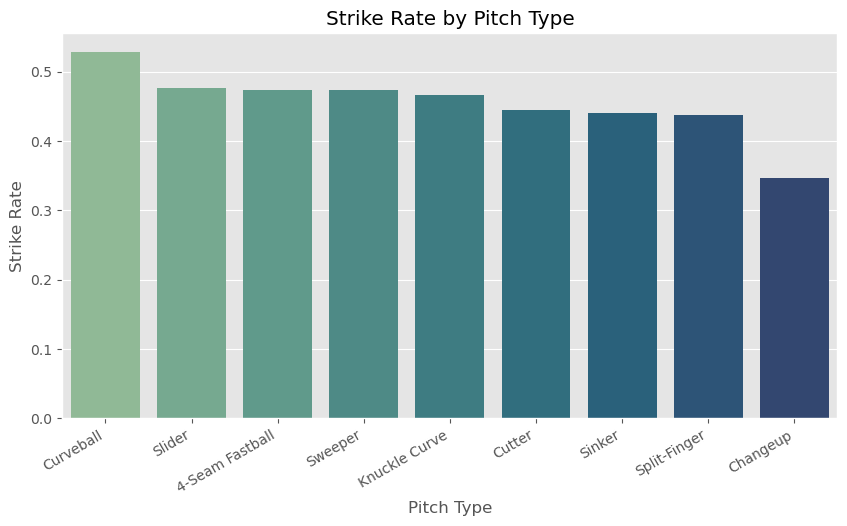

In [34]:
# Strike rate by pitch type: table and graph.

strike_table = pitch_type_summary[["pitches", "strike_rate"]].sort_values("strike_rate", ascending=False)
display(strike_table)

plt.figure(figsize=(10, 5))
sns.barplot(data=strike_table.reset_index(), x="pitch_name", y="strike_rate", palette="crest")
plt.title("Strike Rate by Pitch Type")
plt.xlabel("Pitch Type")
plt.ylabel("Strike Rate")
plt.xticks(rotation=30, ha="right")
plt.show()


,pitches,in_play_rate
pitch_name,,
Sinker,145,0.200
Changeup,127,0.197
4-Seam Fastball,937,0.193
Cutter,196,0.168
Curveball,136,0.147
Slider,540,0.143
Split-Finger,402,0.129
Knuckle Curve,174,0.121
Sweeper,131,0.099


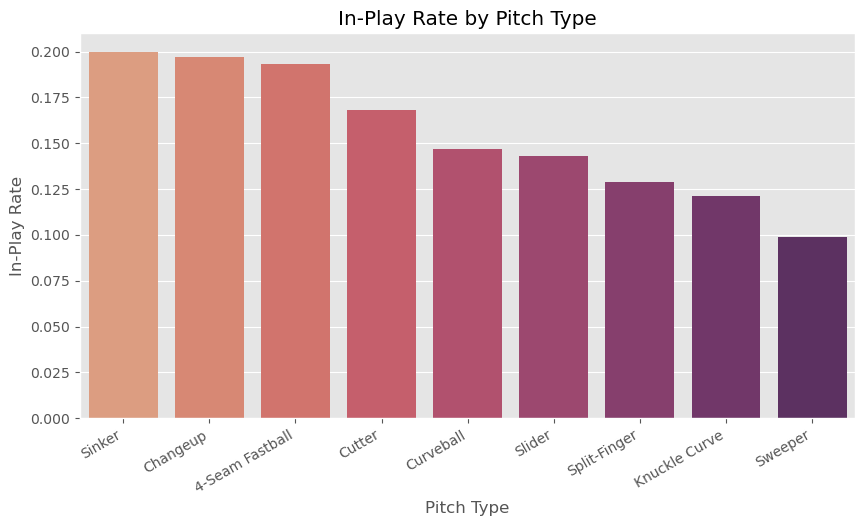

In [35]:
# In-play rate by pitch type: table and graph.

in_play_table = pitch_type_summary[["pitches", "in_play_rate"]].sort_values("in_play_rate", ascending=False)
display(in_play_table)

plt.figure(figsize=(10, 5))
sns.barplot(data=in_play_table.reset_index(), x="pitch_name", y="in_play_rate", palette="flare")
plt.title("In-Play Rate by Pitch Type")
plt.xlabel("Pitch Type")
plt.ylabel("In-Play Rate")
plt.xticks(rotation=30, ha="right")
plt.show()


count_leverage,even,hitter_ahead,pitcher_ahead
pitch_name,,,
4-Seam Fastball,0.495,0.290,0.215
Changeup,0.433,0.220,0.346
Curveball,0.463,0.228,0.309
Cutter,0.459,0.276,0.265
Knuckle Curve,0.431,0.259,0.310
Sinker,0.476,0.386,0.138
Slider,0.413,0.263,0.324
Split-Finger,0.403,0.219,0.378
Sweeper,0.397,0.252,0.351


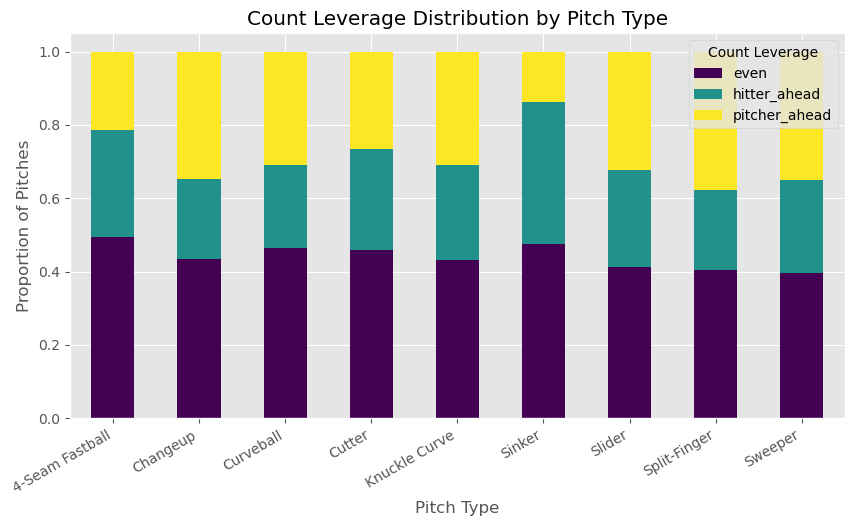

In [36]:
# Count leverage by pitch type: table and stacked graph.

count_leverage_by_pitch = (
    pd.crosstab(bj_clean["pitch_name"], bj_clean["count_leverage"], normalize="index")
    .round(3)
)
display(count_leverage_by_pitch)

count_leverage_by_pitch.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="viridis")
plt.title("Count Leverage Distribution by Pitch Type")
plt.xlabel("Pitch Type")
plt.ylabel("Proportion of Pitches")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Count Leverage", loc="best")
plt.show()


pitch_name,4-Seam Fastball,Slider,Split-Finger,Cutter,Knuckle Curve,Sinker
inning,,,,,,
1,0.412,0.179,0.223,0.053,0.047,0.000
2,0.400,0.254,0.168,0.046,0.032,0.004
3,0.366,0.211,0.188,0.050,0.036,0.003
4,0.337,0.240,0.140,0.081,0.081,0.000
5,0.325,0.159,0.171,0.091,0.083,0.000
6,0.270,0.174,0.135,0.080,0.077,0.090
7,0.330,0.179,0.097,0.067,0.103,0.052
8,0.238,0.121,0.107,0.070,0.064,0.208
9,0.361,0.261,0.132,0.075,0.025,0.079


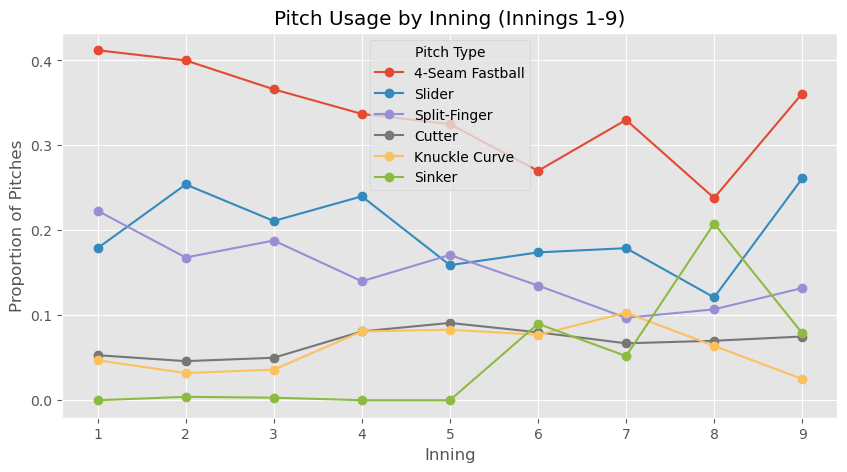

In [37]:
# Pitch usage by inning: focus on innings 1-9 and the most common pitch types.

top_pitch_types = pitch_type_summary.head(6).index

pitch_usage_by_inning = (
    pd.crosstab(
        bj_clean.loc[bj_clean["inning"].between(1, 9), "inning"],
        bj_clean.loc[bj_clean["inning"].between(1, 9), "pitch_name"],
        normalize="index"
    )[list(top_pitch_types)]
    .round(3)
)

display(pitch_usage_by_inning)

pitch_usage_by_inning.plot(figsize=(10, 5), marker="o")
plt.title("Pitch Usage by Inning (Innings 1-9)")
plt.xlabel("Inning")
plt.ylabel("Proportion of Pitches")
plt.legend(title="Pitch Type", loc="best")
plt.show()


### Summary of Findings

- The pitch types separate clearly by role. The **4-Seam Fastball** is the hardest-thrown common pitch at **95.036 mph** and also the most-used at **937 pitches**, while the **Curveball** is the slowest at **79.221 mph**.
- The best swing-and-miss pitch was the **Split-Finger**, with a **0.231 whiff rate**, followed by the **Slider (0.185)** and **Sweeper (0.176)**. In contrast, the **4-Seam Fastball** generated only a **0.065 whiff rate**, so it looks more like a setup pitch than a primary put-away pitch.
- The **Curveball** had the highest strike rate at **0.529**, while the **Changeup** had the lowest at **0.346**. For balls in play, the **Sinker (0.200)** and **Changeup (0.197)** were the most contact-oriented pitches.
- Usage also shifts by situation. The **Split-Finger** was used most often when the pitcher was ahead (**37.8%** of split-fingers), and the **Sinker** was used far more often in hitter-ahead counts (**38.6%**) than in pitcher-ahead counts (**13.8%**). By inning, 4-seam usage fell from **41.2% in the 1st** to **23.8% in the 8th**, while sinker usage rose to **20.8% in the 8th**.

# Do Blue Jays pitchers perform differently as postseason series progressed
- As series goes on
- As entire postseason goes on


## 1. How do Blue Jays pitchers perform as a series goes 
starting with finding out how much data we have on each game number to see if we need to combine it into early middle and late

In [41]:
# Step 1: identify game order within each postseason series
games = (
    bj_clean[["game_pk", "game_date", "home_team", "away_team"]]
    .drop_duplicates()
    .sort_values("game_date")
    .copy()
)

# Opponent is whichever team is not Toronto
games["opponent"] = games.apply(
    lambda row: row["away_team"] if row["home_team"] == "TOR" else row["home_team"],
    axis=1
)

# Number games within each opponent series
games["game_number_in_series"] = games.groupby("opponent").cumcount() + 1

# Count pitches in each game
pitch_counts_by_game = (
    bj_clean.groupby("game_pk")
    .size()
    .reset_index(name="pitch_count")
)

# Merge game order with pitch counts
series_game_summary = (
    games.merge(pitch_counts_by_game, on="game_pk")
    .sort_values(["opponent", "game_number_in_series"])
)

display(series_game_summary)

# Step 2: summarize how much data exists for each game number overall
game_number_counts = (
    series_game_summary.groupby("game_number_in_series")
    .agg(
        games=("game_pk", "size"),
        total_pitches=("pitch_count", "sum"),
        avg_pitches=("pitch_count", "mean")
    )
    .round(1)
    .reset_index()
)

display(game_number_counts)


,game_pk,game_date,home_team,away_team,opponent,game_number_in_series,pitch_count
11,813027,2025-10-24,TOR,LAD,LAD,1,171
12,813026,2025-10-25,TOR,LAD,LAD,2,117
13,813032,2025-10-27,LAD,TOR,LAD,3,297
14,813023,2025-10-28,LAD,TOR,LAD,4,125
15,813022,2025-10-29,LAD,TOR,LAD,5,139
16,813025,2025-10-31,TOR,LAD,LAD,6,141
17,813024,2025-11-01,TOR,LAD,LAD,7,172
0,813063,2025-10-04,TOR,NYY,NYY,1,129
1,813062,2025-10-05,TOR,NYY,NYY,2,168
2,813061,2025-10-07,NYY,TOR,NYY,3,148


,game_number_in_series,games,total_pitches,avg_pitches
0,1,3,450,150.0
1,2,3,467,155.7
2,3,3,580,193.3
3,4,3,406,135.3
4,5,2,288,144.0
5,6,2,285,142.5
6,7,2,312,156.0


There's a dib in data after game 5 since TOR swept the Yankees, but we will keep it seperate and not combine into early mid and late games of the series

## Series Progression Analysis

Because the pitch counts by game number were still workable, we will keep each game number separate instead of combining them into early, middle, and late stages.

In the cells below, `series_stage` means the game number within a postseason series, labeled as `Game 1`, `Game 2`, and so on.

In [44]:
# Build a game-number-based series_stage variable and merge it into bj_clean.

series_games = (
    bj_clean[["game_pk", "game_date", "home_team", "away_team"]]
    .drop_duplicates()
    .sort_values("game_date")
    .copy()
)

series_games["opponent"] = series_games.apply(
    lambda row: row["away_team"] if row["home_team"] == "TOR" else row["home_team"],
    axis=1
)

series_games["game_number_in_series"] = series_games.groupby("opponent").cumcount() + 1
series_games["series_stage"] = "Game " + series_games["game_number_in_series"].astype(str)

bj_series = bj_clean.merge(
    series_games[["game_pk", "opponent", "game_number_in_series", "series_stage"]],
    on="game_pk",
    how="left"
)

series_stage_order = [f"Game {i}" for i in sorted(bj_series["game_number_in_series"].dropna().unique())]
bj_series["series_stage"] = pd.Categorical(bj_series["series_stage"], categories=series_stage_order, ordered=True)

display(series_games.sort_values(["opponent", "game_number_in_series"]))


,game_pk,game_date,home_team,away_team,opponent,game_number_in_series,series_stage
1626,813027,2025-10-24,TOR,LAD,LAD,1,Game 1
1797,813026,2025-10-25,TOR,LAD,LAD,2,Game 2
1914,813032,2025-10-27,LAD,TOR,LAD,3,Game 3
2211,813023,2025-10-28,LAD,TOR,LAD,4,Game 4
2336,813022,2025-10-29,LAD,TOR,LAD,5,Game 5
2475,813025,2025-10-31,TOR,LAD,LAD,6,Game 6
2616,813024,2025-11-01,TOR,LAD,LAD,7,Game 7
0,813063,2025-10-04,TOR,NYY,NYY,1,Game 1
129,813062,2025-10-05,TOR,NYY,NYY,2,Game 2
297,813061,2025-10-07,NYY,TOR,NYY,3,Game 3


### Average `is_strike` by `series_stage`

This checks whether Blue Jays pitchers throw strikes more or less often as each series moves from Game 1 to later games.

,pitches,strike_rate
series_stage,,
Game 1,450,0.464
Game 2,467,0.484
Game 3,580,0.457
Game 4,406,0.443
Game 5,288,0.472
Game 6,285,0.512
Game 7,312,0.401


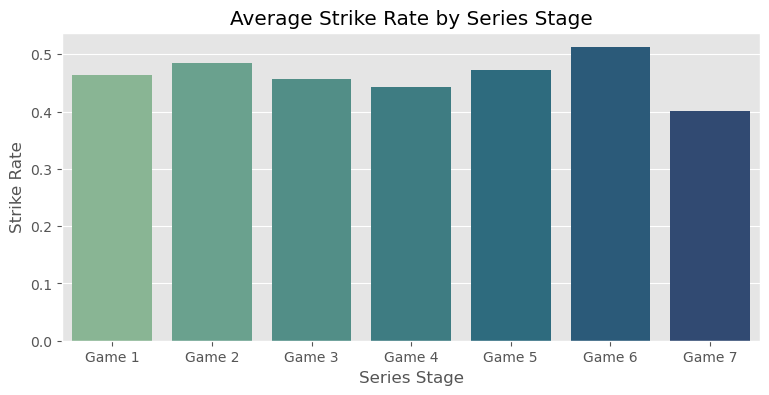

In [46]:
# Average strike rate by series stage.

series_strike_summary = (
    bj_series
    .groupby("series_stage")
    .agg(pitches=("game_pk", "size"), strike_rate=("is_strike", "mean"))
    .round(3)
)

display(series_strike_summary)

plt.figure(figsize=(9, 4))
sns.barplot(data=series_strike_summary.reset_index(), x="series_stage", y="strike_rate", palette="crest")
plt.title("Average Strike Rate by Series Stage")
plt.xlabel("Series Stage")
plt.ylabel("Strike Rate")
plt.show()


### Average `is_whiff` by `series_stage`

This checks whether swing-and-miss effectiveness changes from earlier games to later games in a series.

,pitches,whiff_rate
series_stage,,
Game 1,450,0.144
Game 2,467,0.120
Game 3,580,0.121
Game 4,406,0.106
Game 5,288,0.156
Game 6,285,0.179
Game 7,312,0.122


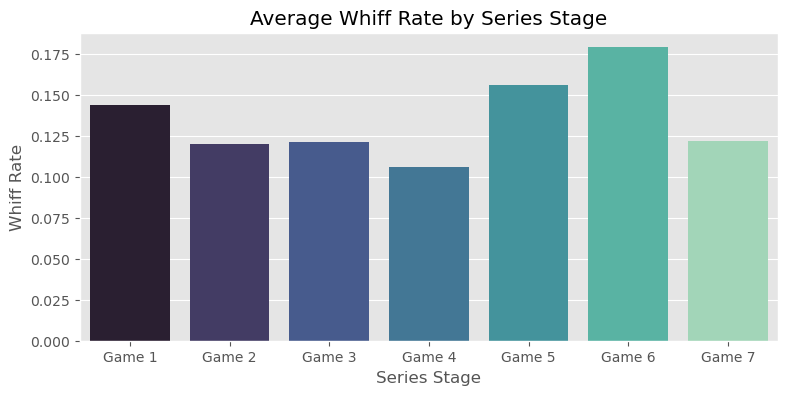

In [48]:
# Average whiff rate by series stage.

series_whiff_summary = (
    bj_series
    .groupby("series_stage")
    .agg(pitches=("game_pk", "size"), whiff_rate=("is_whiff", "mean"))
    .round(3)
)

display(series_whiff_summary)

plt.figure(figsize=(9, 4))
sns.barplot(data=series_whiff_summary.reset_index(), x="series_stage", y="whiff_rate", palette="mako")
plt.title("Average Whiff Rate by Series Stage")
plt.xlabel("Series Stage")
plt.ylabel("Whiff Rate")
plt.show()


### Average `release_speed` by `series_stage`

This checks whether average velocity changes as a series progresses.

In [50]:
# Average release speed by series stage.

series_velocity_summary = (
    bj_series
    .groupby("series_stage")
    .agg(pitches=("game_pk", "size"), avg_release_speed=("release_speed", "mean"))
    .round(3)
)

display(series_velocity_summary)



,pitches,avg_release_speed
series_stage,,
Game 1,450,90.673
Game 2,467,89.512
Game 3,580,89.509
Game 4,406,89.722
Game 5,288,89.840
Game 6,285,89.193
Game 7,312,88.449


### Pitch-Type Usage by `series_stage`

This checks whether pitch selection changes as the series moves from Game 1 to later games. To keep the graph readable, we focus on the most common pitch types.

pitch_name,4-Seam Fastball,Slider,Split-Finger,Cutter,Knuckle Curve,Sinker
series_stage,,,,,,
Game 1,0.418,0.156,0.189,0.053,0.040,0.051
Game 2,0.379,0.184,0.180,0.043,0.036,0.039
Game 3,0.295,0.209,0.024,0.134,0.095,0.066
Game 4,0.323,0.140,0.049,0.135,0.076,0.054
Game 5,0.351,0.257,0.271,0.007,0.038,0.038
Game 6,0.323,0.182,0.330,0.021,0.063,0.028
Game 7,0.247,0.256,0.087,0.035,0.077,0.080


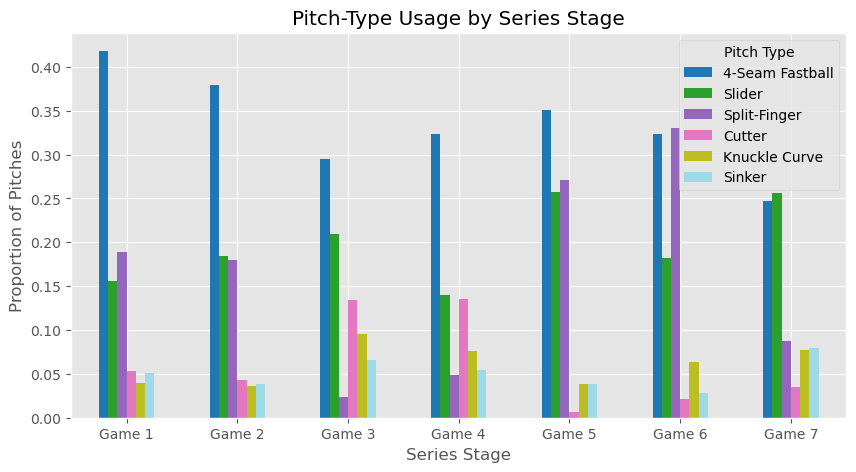

In [52]:
# Pitch-type usage by series stage.

top_stage_pitch_types = bj_series["pitch_name"].value_counts().head(6).index

series_pitch_usage = (
    pd.crosstab(bj_series["series_stage"], bj_series["pitch_name"], normalize="index")
    [list(top_stage_pitch_types)]
    .round(3)
)

display(series_pitch_usage)

series_pitch_usage.plot(kind="bar", figsize=(10, 5), colormap="tab20")
plt.title("Pitch-Type Usage by Series Stage")
plt.xlabel("Series Stage")
plt.ylabel("Proportion of Pitches")
plt.xticks(rotation=0)
plt.legend(title="Pitch Type", loc="best")
plt.show()


### Most-Used Pitchers by `series_stage`

This final summary looks at the most-used pitchers and how their workloads and basic results vary across series stages.

,series_stage,player_name,pitches,strike_rate,whiff_rate,avg_release_speed
0,Game 1,"Bieber, Shane",0,NaN,NaN,NaN
1,Game 1,"Gausman, Kevin",151,0.444,0.146,90.221
2,Game 1,"Hoffman, Jeff",32,0.500,0.125,92.872
3,Game 1,"Scherzer, Max",0,NaN,NaN,NaN
4,Game 1,"Varland, Louis",37,0.486,0.135,95.276
5,Game 1,"Yesavage, Trey",80,0.425,0.162,90.315
6,Game 2,"Bieber, Shane",0,NaN,NaN,NaN
7,Game 2,"Gausman, Kevin",82,0.500,0.122,90.671
8,Game 2,"Hoffman, Jeff",8,0.500,0.125,87.988
9,Game 2,"Scherzer, Max",0,NaN,NaN,NaN


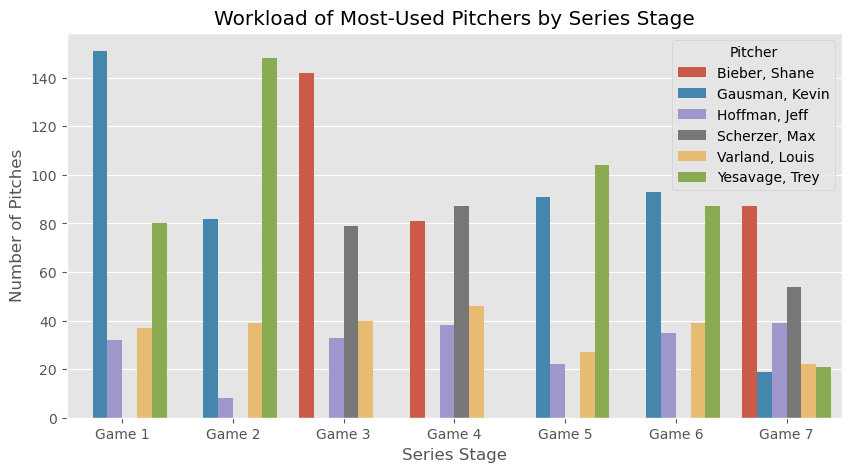

In [54]:
# Pitcher-specific summary for the most-used pitchers.

most_used_pitchers = bj_series["player_name"].value_counts().head(6).index

series_pitcher_summary = (
    bj_series[bj_series["player_name"].isin(most_used_pitchers)]
    .groupby(["series_stage", "player_name"])
    .agg(
        pitches=("game_pk", "size"),
        strike_rate=("is_strike", "mean"),
        whiff_rate=("is_whiff", "mean"),
        avg_release_speed=("release_speed", "mean")
    )
    .round(3)
    .reset_index()
)

display(series_pitcher_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=series_pitcher_summary, x="series_stage", y="pitches", hue="player_name")
plt.title("Workload of Most-Used Pitchers by Series Stage")
plt.xlabel("Series Stage")
plt.ylabel("Number of Pitches")
plt.legend(title="Pitcher", loc="best")
plt.show()


### Summary of Findings

- Strike rate did not move in one simple direction across a series. It ranged from **0.401 in Game 7** to **0.512 in Game 6**, with Games **1 to 4** clustered between **0.443** and **0.484**. That suggests variation, but not a clear steady decline.
- Whiff rate also fluctuated rather than trending smoothly. It was lowest in **Game 4 (0.106)** and highest in **Game 6 (0.179)**, while the other games stayed in a narrower band between **0.120** and **0.156**.
- Average velocity was relatively stable through Games **1 to 6** at about **89.2 to 90.7 mph**, but dropped to **88.449 mph in Game 7**. That late drop is worth noting, although Game 7 still had only **312 pitches**, so it should be interpreted cautiously.
- Pitch mix changed meaningfully by game number. For example, **4-Seam Fastball** usage fell from **41.8% in Game 1** to **24.7% in Game 7**, while **Split-Finger** usage peaked at **33.0% in Game 6**. Pitcher usage also changed by stage, so part of the series effect may reflect who was on the mound rather than a pure progression effect.

## 2. Performance as Postseason Continues

This section repeats the same type of progression analysis, but now across the **entire postseason** rather than within each individual series.

Here, each stage represents the Blue Jays' overall postseason game number, from **Postseason Game 1** through **Postseason Game 18**. Because each stage is one game, the results should be interpreted as game-by-game postseason trends rather than averaged series stages.

In [57]:
# Build an overall postseason game-order variable and merge it into bj_clean.

postseason_games = (
    bj_clean[["game_pk", "game_date", "home_team", "away_team"]]
    .drop_duplicates()
    .sort_values(["game_date", "game_pk"])
    .copy()
)

postseason_games["opponent"] = postseason_games.apply(
    lambda row: row["away_team"] if row["home_team"] == "TOR" else row["home_team"],
    axis=1
)

postseason_games["postseason_game_number"] = range(1, len(postseason_games) + 1)
postseason_games["postseason_stage"] = "Postseason Game " + postseason_games["postseason_game_number"].astype(str)

bj_postseason = bj_clean.merge(
    postseason_games[["game_pk", "opponent", "postseason_game_number", "postseason_stage"]],
    on="game_pk",
    how="left"
)

display(postseason_games)


,game_pk,game_date,home_team,away_team,opponent,postseason_game_number,postseason_stage
0,813063,2025-10-04,TOR,NYY,NYY,1,Postseason Game 1
129,813062,2025-10-05,TOR,NYY,NYY,2,Postseason Game 2
297,813061,2025-10-07,NYY,TOR,NYY,3,Postseason Game 3
445,813060,2025-10-08,NYY,TOR,NYY,4,Postseason Game 4
597,813040,2025-10-12,TOR,SEA,SEA,5,Postseason Game 5
747,813044,2025-10-13,TOR,SEA,SEA,6,Postseason Game 6
929,813043,2025-10-15,SEA,TOR,SEA,7,Postseason Game 7
1064,813035,2025-10-16,SEA,TOR,SEA,8,Postseason Game 8
1193,813039,2025-10-17,SEA,TOR,SEA,9,Postseason Game 9
1342,813038,2025-10-19,TOR,SEA,SEA,10,Postseason Game 10


### Average `is_strike` by Overall Postseason Stage

This checks whether strike rate changed as the Blue Jays moved from their first postseason game to their final one.

,postseason_game_number,postseason_stage,pitches,strike_rate
0,1,Postseason Game 1,129,0.465
1,2,Postseason Game 2,168,0.488
2,3,Postseason Game 3,148,0.426
3,4,Postseason Game 4,152,0.454
4,5,Postseason Game 5,150,0.453
5,6,Postseason Game 6,182,0.500
6,7,Postseason Game 7,135,0.474
7,8,Postseason Game 8,129,0.457
8,9,Postseason Game 9,149,0.389
9,10,Postseason Game 10,144,0.500


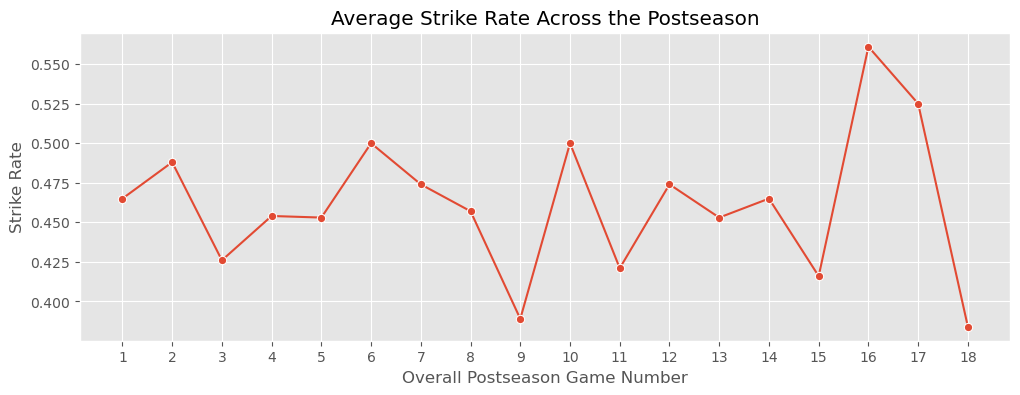

In [59]:
# Average strike rate by overall postseason game number.

postseason_strike_summary = (
    bj_postseason
    .groupby(["postseason_game_number", "postseason_stage"])
    .agg(pitches=("game_pk", "size"), strike_rate=("is_strike", "mean"))
    .round(3)
    .reset_index()
)

display(postseason_strike_summary)

plt.figure(figsize=(12, 4))
sns.lineplot(data=postseason_strike_summary, x="postseason_game_number", y="strike_rate", marker="o")
plt.title("Average Strike Rate Across the Postseason")
plt.xlabel("Overall Postseason Game Number")
plt.ylabel("Strike Rate")
plt.xticks(postseason_strike_summary["postseason_game_number"])
plt.show()


### Average `is_whiff` by Overall Postseason Stage

This checks whether swing-and-miss effectiveness changed across the full postseason schedule.

,postseason_game_number,postseason_stage,pitches,whiff_rate
0,1,Postseason Game 1,129,0.140
1,2,Postseason Game 2,168,0.149
2,3,Postseason Game 3,148,0.128
3,4,Postseason Game 4,152,0.125
4,5,Postseason Game 5,150,0.153
5,6,Postseason Game 6,182,0.110
6,7,Postseason Game 7,135,0.148
7,8,Postseason Game 8,129,0.116
8,9,Postseason Game 9,149,0.141
9,10,Postseason Game 10,144,0.153


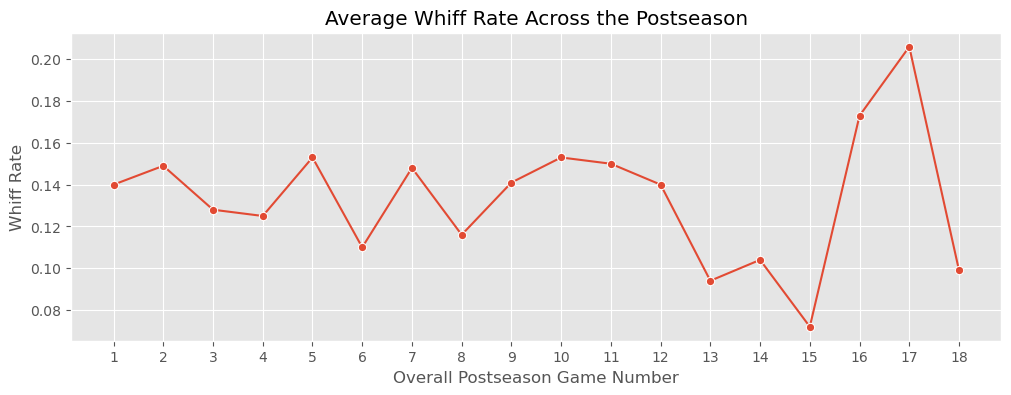

In [61]:
# Average whiff rate by overall postseason game number.

postseason_whiff_summary = (
    bj_postseason
    .groupby(["postseason_game_number", "postseason_stage"])
    .agg(pitches=("game_pk", "size"), whiff_rate=("is_whiff", "mean"))
    .round(3)
    .reset_index()
)

display(postseason_whiff_summary)

plt.figure(figsize=(12, 4))
sns.lineplot(data=postseason_whiff_summary, x="postseason_game_number", y="whiff_rate", marker="o")
plt.title("Average Whiff Rate Across the Postseason")
plt.xlabel("Overall Postseason Game Number")
plt.ylabel("Whiff Rate")
plt.xticks(postseason_whiff_summary["postseason_game_number"])
plt.show()


### Average `release_speed` by Overall Postseason Stage

This checks whether average velocity shifted as the postseason went on.

,postseason_game_number,postseason_stage,pitches,avg_release_speed
0,1,Postseason Game 1,129,91.869
1,2,Postseason Game 2,168,89.269
2,3,Postseason Game 3,148,90.482
3,4,Postseason Game 4,152,89.401
4,5,Postseason Game 5,150,91.157
5,6,Postseason Game 6,182,89.071
6,7,Postseason Game 7,135,87.956
7,8,Postseason Game 8,129,90.690
8,9,Postseason Game 9,149,90.072
9,10,Postseason Game 10,144,89.601


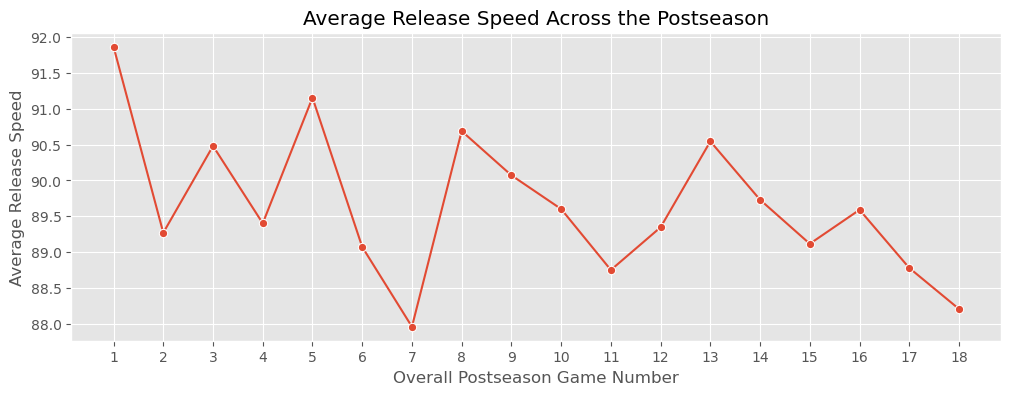

In [63]:
# Average release speed by overall postseason game number.

postseason_velocity_summary = (
    bj_postseason
    .groupby(["postseason_game_number", "postseason_stage"])
    .agg(pitches=("game_pk", "size"), avg_release_speed=("release_speed", "mean"))
    .round(3)
    .reset_index()
)

display(postseason_velocity_summary)

plt.figure(figsize=(12, 4))
sns.lineplot(data=postseason_velocity_summary, x="postseason_game_number", y="avg_release_speed", marker="o")
plt.title("Average Release Speed Across the Postseason")
plt.xlabel("Overall Postseason Game Number")
plt.ylabel("Average Release Speed")
plt.xticks(postseason_velocity_summary["postseason_game_number"])
plt.show()


### Pitch-Type Usage by Overall Postseason Stage

This checks whether pitch selection changed from the start of the postseason to the end. To keep the graph readable, we focus on the most common pitch types.

pitch_name,4-Seam Fastball,Slider,Split-Finger,Cutter,Knuckle Curve,Sinker
postseason_stage,,,,,,
Postseason Game 1,0.465,0.039,0.302,0.031,0.054,0.062
Postseason Game 10,0.347,0.264,0.312,0.000,0.056,0.007
Postseason Game 11,0.257,0.271,0.093,0.021,0.107,0.057
Postseason Game 12,0.368,0.269,0.064,0.088,0.000,0.053
Postseason Game 13,0.479,0.179,0.256,0.000,0.060,0.000
Postseason Game 14,0.367,0.162,0.034,0.104,0.064,0.081
Postseason Game 15,0.328,0.096,0.000,0.192,0.168,0.080
Postseason Game 16,0.331,0.403,0.252,0.000,0.000,0.007
Postseason Game 17,0.298,0.099,0.348,0.043,0.071,0.050


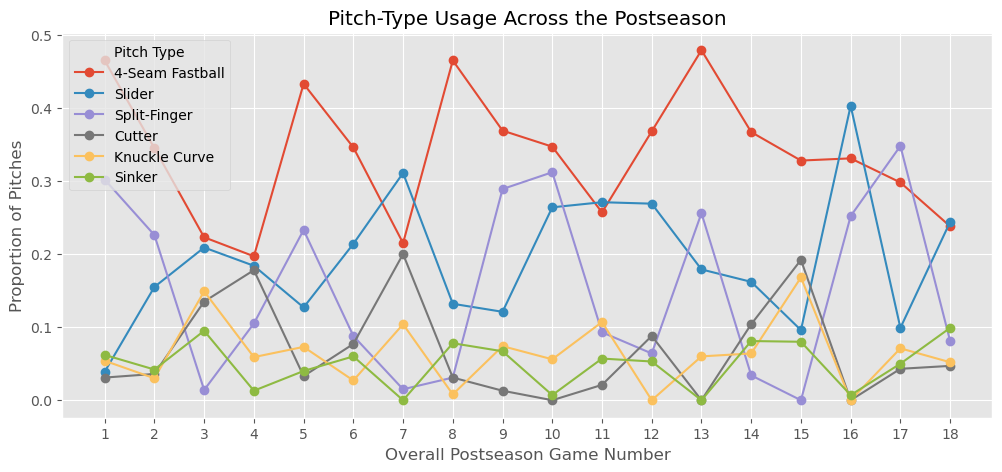

In [65]:
# Pitch-type usage by overall postseason game number.

top_postseason_pitch_types = bj_postseason["pitch_name"].value_counts().head(6).index

postseason_pitch_usage = (
    pd.crosstab(bj_postseason["postseason_stage"], bj_postseason["pitch_name"], normalize="index")
    [list(top_postseason_pitch_types)]
    .round(3)
)

display(postseason_pitch_usage)

postseason_pitch_usage_numeric = (
    pd.crosstab(bj_postseason["postseason_game_number"], bj_postseason["pitch_name"], normalize="index")
    [list(top_postseason_pitch_types)]
    .round(3)
)

postseason_pitch_usage_numeric.plot(figsize=(12, 5), marker="o")
plt.title("Pitch-Type Usage Across the Postseason")
plt.xlabel("Overall Postseason Game Number")
plt.ylabel("Proportion of Pitches")
plt.xticks(postseason_pitch_usage_numeric.index)
plt.legend(title="Pitch Type", loc="best")
plt.show()


### Most-Used Pitchers Across the Postseason

This final summary checks how the most-used pitchers' workloads and basic results changed from one postseason game to the next.

,postseason_game_number,postseason_stage,player_name,pitches,strike_rate,whiff_rate,avg_release_speed
0,1,Postseason Game 1,"Gausman, Kevin",75,0.453,0.160,90.235
1,1,Postseason Game 1,"Hoffman, Jeff",17,0.529,0.118,94.818
2,1,Postseason Game 1,"Varland, Louis",16,0.562,0.125,95.138
3,2,Postseason Game 2,"Varland, Louis",10,0.300,0.100,92.900
4,2,Postseason Game 2,"Yesavage, Trey",78,0.538,0.218,89.742
5,3,Postseason Game 3,"Bieber, Shane",54,0.444,0.093,89.033
6,3,Postseason Game 3,"Varland, Louis",20,0.500,0.250,94.790
7,4,Postseason Game 4,"Hoffman, Jeff",26,0.423,0.269,89.777
8,4,Postseason Game 4,"Varland, Louis",20,0.450,0.100,95.465
9,5,Postseason Game 5,"Gausman, Kevin",76,0.434,0.132,90.207


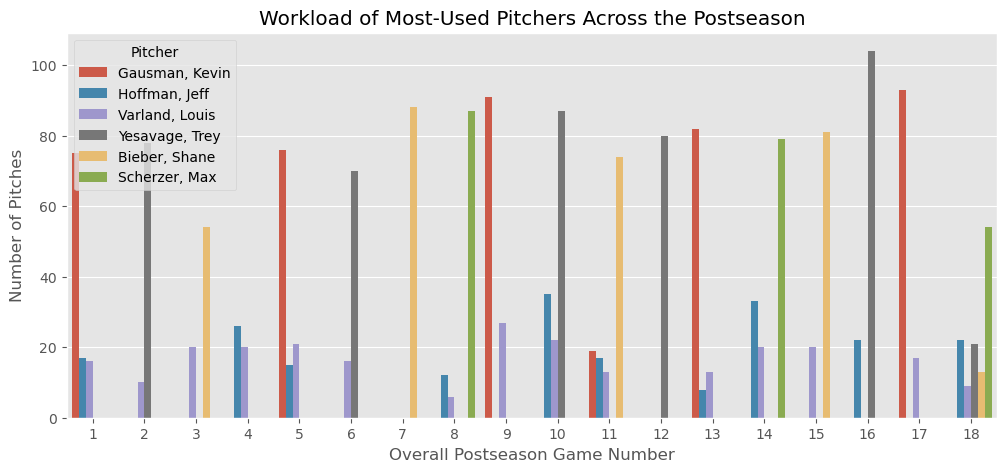

In [67]:
# Pitcher-specific summary for the most-used pitchers across the full postseason.

most_used_postseason_pitchers = bj_postseason["player_name"].value_counts().head(6).index

postseason_pitcher_summary = (
    bj_postseason[bj_postseason["player_name"].isin(most_used_postseason_pitchers)]
    .groupby(["postseason_game_number", "postseason_stage", "player_name"])
    .agg(
        pitches=("game_pk", "size"),
        strike_rate=("is_strike", "mean"),
        whiff_rate=("is_whiff", "mean"),
        avg_release_speed=("release_speed", "mean")
    )
    .round(3)
    .reset_index()
)

display(postseason_pitcher_summary)

plt.figure(figsize=(12, 5))
sns.barplot(data=postseason_pitcher_summary, x="postseason_game_number", y="pitches", hue="player_name")
plt.title("Workload of Most-Used Pitchers Across the Postseason")
plt.xlabel("Overall Postseason Game Number")
plt.ylabel("Number of Pitches")
plt.legend(title="Pitcher", loc="best")
plt.show()


### Summary of Findings

- Across the full postseason, strike rate fluctuated from game to game rather than moving in a straight trend. It ranged from **0.384 in Postseason Game 18** to **0.561 in Postseason Game 16**.
- Whiff rate also varied by game, with a low of **0.072 in Postseason Game 15** and highs of **0.206 in Postseason Game 17** and **0.173 in Postseason Game 16**. That suggests some of the strongest swing-and-miss results came very late in the postseason.
- Average velocity started high in **Postseason Game 1 (91.869 mph)**, stayed mostly in the **88 to 91 mph** range through the middle, and ended at **88.204 mph in Postseason Game 18**. That hints at some late-postseason decline in raw velocity, though not a perfectly smooth one.
- Pitch usage changed meaningfully over time. For example, **4-Seam Fastball** usage dropped from **46.5% in Postseason Game 1** to **23.8% in Postseason Game 18**, while **Slider** usage peaked at **40.3% in Postseason Game 16** and **Split-Finger** usage reached **34.8% in Postseason Game 17**. As with the series analysis, part of this likely reflects which pitchers were used in each game.

**Pitch types and locations that generates the most swing and miss for Blue Jays pitchers**

Overall Swing and miss rate for all pitches:

In [71]:
overall_whiff_rate = bj_clean["is_whiff"].mean()

print(f"Overall swing-and-miss rate: {overall_whiff_rate:.3f} ({overall_whiff_rate*100:.2f}%)")

Overall swing-and-miss rate: 0.132 (13.20%)


Across all of the pitches thrown by Blue Jays pitchers during the 2025 postseason, the overall swing-and-miss rate was 13.2%. This serves as a baseline for comparing the effectiveness of specific pitch types and pitch locations. Pitch types or zones with whiff rates significantly above this baseline can be considered particularly effective at generating missed swings.

Whiff rate by pitch types

In [74]:
whiff_by_pitch = (
    bj_clean.groupby("pitch_name")
    .agg(
        total_pitches=("pitch_name","count"),
        whiffs=("is_whiff","sum"),
        whiff_rate=("is_whiff","mean")
    )
    .sort_values("whiff_rate", ascending=False)
)

print(whiff_by_pitch)

                 total_pitches  whiffs  whiff_rate
pitch_name                                        
Split-Finger               402      93    0.231343
Slider                     540     100    0.185185
Sweeper                    131      23    0.175573
Knuckle Curve              174      30    0.172414
Curveball                  136      17    0.125000
Cutter                     196      21    0.107143
Changeup                   127      13    0.102362
Sinker                     145      10    0.068966
4-Seam Fastball            937      61    0.065101


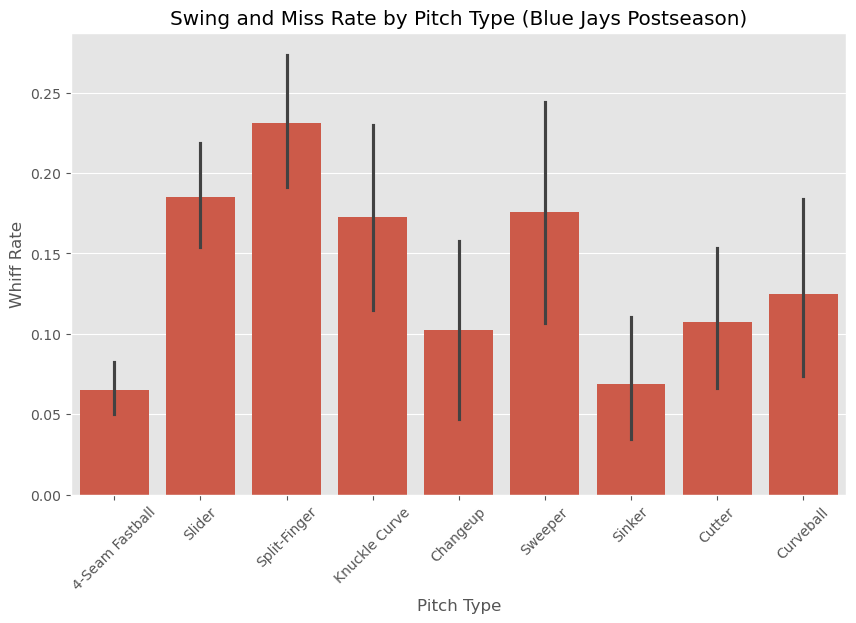

In [75]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=bj_clean,
    x="pitch_name",
    y="is_whiff"
)

plt.title("Swing and Miss Rate by Pitch Type (Blue Jays Postseason)")
plt.ylabel("Whiff Rate")
plt.xlabel("Pitch Type")
plt.xticks(rotation=45)

plt.show()

Key Findings:
- Split-finger fastballs generated the highest whiff rate (23.1%), nearly double the overall average.
- Breaking pitches (sliders, sweepers, knuckle curves) consistently produced high swing-and-miss rates.
- Fastballs and sinkers produced the lowest whiff rates, which could indicate that they are more often used to induce contact rather than misses.

The findings indicate that off-speed and breaking pitches are the most effective at generating swings and misses. The split-finger produced the highest whiff rate at 23.1%, followed by sliders (18.5%) and sweepers (17.6%). In contrast, fastballs and sinkers generated substantially lower whiff rates, both below 7%. This would line up with typical baseball strategy, where breaking pitches are used as strikeout pitches due to their movement and deception.

Whiff rate by zone location

In [78]:
zone_whiff = (
    bj_clean.groupby("zone")
    .agg(
        total_pitches=("zone","count"),
        whiffs=("is_whiff","sum"),
        whiff_rate=("is_whiff","mean")
    )
    .sort_values("whiff_rate", ascending=False)
)

print(zone_whiff)

      total_pitches  whiffs  whiff_rate
zone                                   
13              366      71    0.193989
8               198      36    0.181818
14              591     105    0.177665
3               113      19    0.168142
7               115      19    0.165217
9               137      17    0.124088
6               154      18    0.116883
1                95      11    0.115789
5               195      18    0.092308
2               160      13    0.081250
12              213      15    0.070423
11              295      18    0.061017
4               156       8    0.051282


Pitch location also plays an important role in generating swings and misses. The highest whiff rates occurred in zones 13, 8, and 14, all of which are located toward the lower or outer edges of the strike zone. These locations are often difficult for hitters to square up and often produce chasing swings.

In contrast, pitches located in zone 4 and zone 11 produced the lowest whiff rates, suggesting that pitches in these areas are easier for hitters to track and make contact with.

To see what each zone number refers to, see the following image, where 1 to 9 is the strike zone and 11-14 are outside the strike zone.

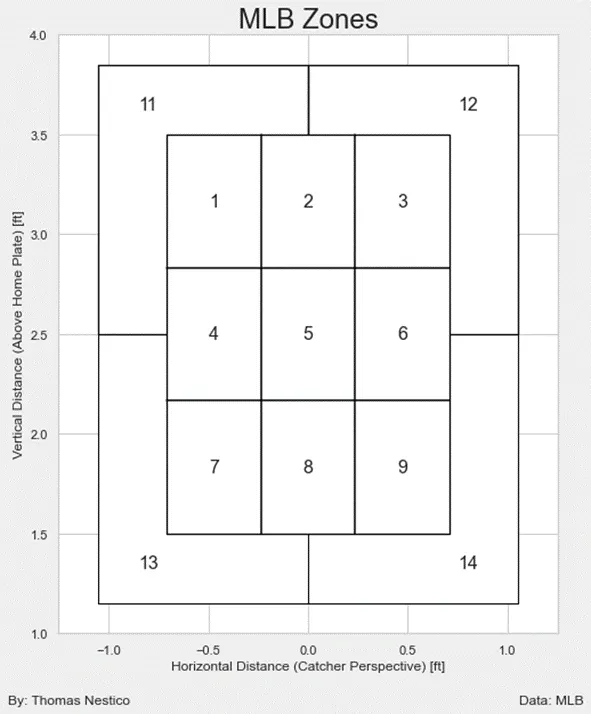

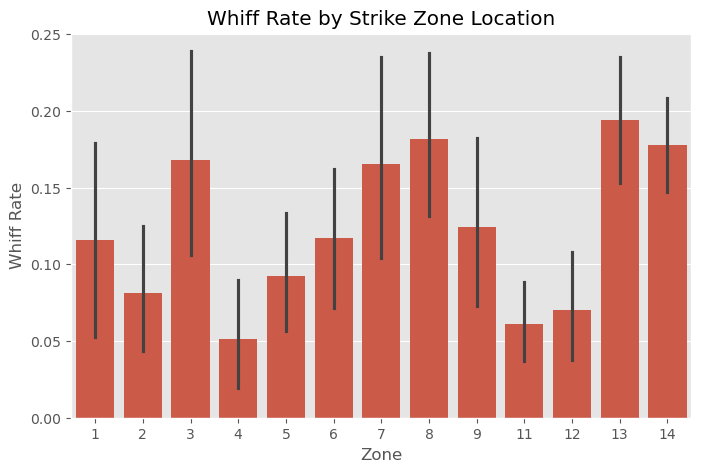

In [117]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=bj_clean,
    x="zone",
    y="is_whiff",
    estimator=np.mean
)

plt.title("Whiff Rate by Strike Zone Location")
plt.ylabel("Whiff Rate")
plt.xlabel("Zone")

plt.show()

Strike Zone Heatmap

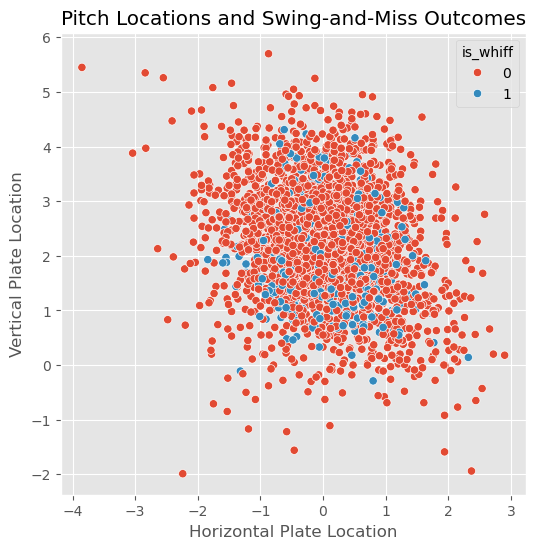

In [146]:
plt.figure(figsize=(6,6))

sns.scatterplot(
    data=bj_clean,
    x="plate_x",
    y="plate_z",
    hue="is_whiff",
    alpha=1
)

plt.title("Pitch Locations and Swing-and-Miss Outcomes")
plt.xlabel("Horizontal Plate Location")
plt.ylabel("Vertical Plate Location")

plt.show()

Pitch Type and Zone Heatmap

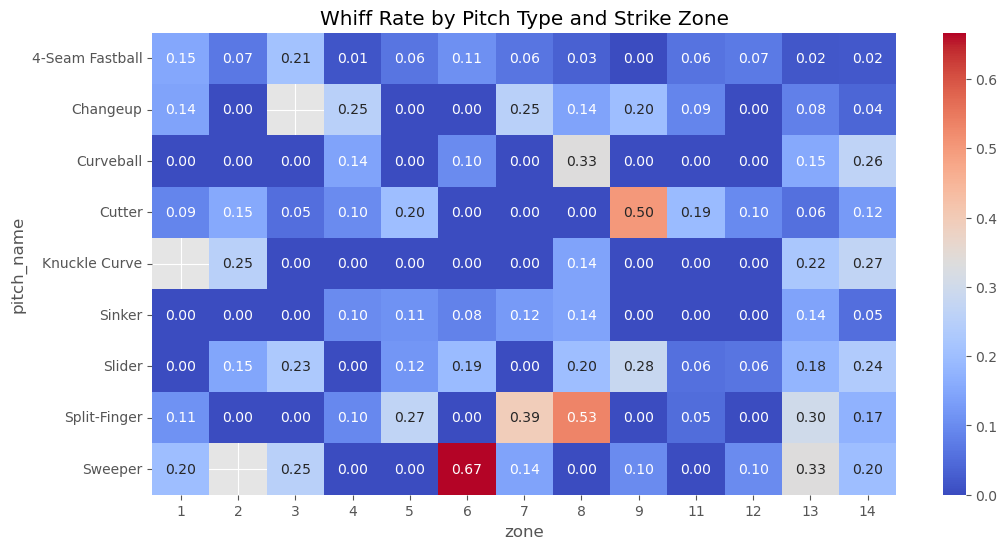

In [126]:
pitch_zone_whiff = bj_clean.pivot_table(
    values="is_whiff",
    index="pitch_name",
    columns="zone",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pitch_zone_whiff,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Whiff Rate by Pitch Type and Strike Zone")

plt.show()

The heatmap shows which pitch types are most effective for each zone. A sweeper has the highest whiff rate in zone 6. While a Split-Finger has a higher whiff rate in zones 7 and 8.

Strike Zone Density Map

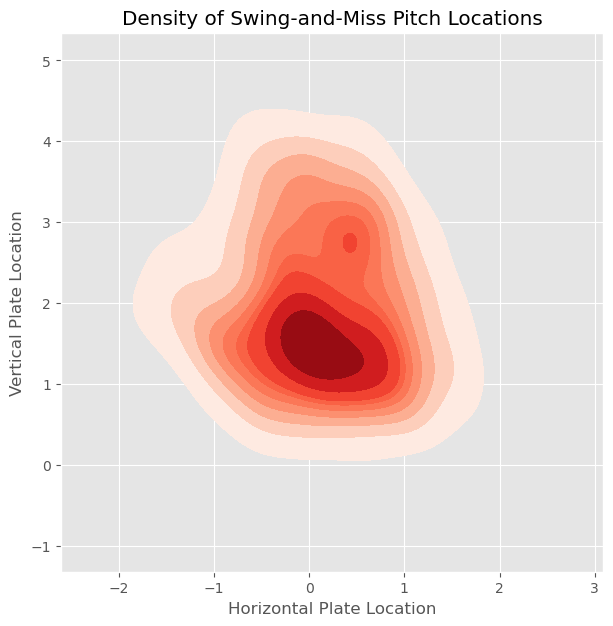

In [130]:
plt.figure(figsize=(7,7))

sns.kdeplot(
    data=bj_clean[bj_clean["is_whiff"] == 1],
    x="plate_x",
    y="plate_z",
    fill=True,
    cmap="Reds",
    thresh=0.05
)

plt.title("Density of Swing-and-Miss Pitch Locations")
plt.xlabel("Horizontal Plate Location")
plt.ylabel("Vertical Plate Location")

plt.show()

The density graph shows that the swing and miss pitches are located in a cluster near the bottom of the strike zone, which would make sense since hitters have difficulty making contact with those types of pitches.

Statistical Testing for pitches and whiff rates

In [134]:
import scipy.stats as stats
groups = [
    group["is_whiff"].values
    for name, group in bj_clean.groupby("pitch_name")
]

f_stat, p_value = stats.f_oneway(*groups)

print(f"ANOVA F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.5f}")

ANOVA F-statistic: 12.432
P-value: 0.00000


The ANOVA test indicates that swing-and-miss rates differ significantly across pitch types. This means that the observed differences in whiff rates between pitches such as split-finger fastballs, sliders, and fastballs are unlikely to be due to random variation. Pitch type has a statistically significant effect on the probability of generating a swing and miss.

Logistic Regression Model - Predicting probability of a swing and miss

In [150]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

model_df = bj_clean.copy()

le = LabelEncoder()
model_df["pitch_type_encoded"] = le.fit_transform(model_df["pitch_type"])

features = [
    "pitch_type_encoded",
    "release_speed",
    "release_spin_rate",
    "plate_x",
    "plate_z",
    "balls",
    "strikes"
]

model_df = model_df.dropna(subset=features)

X = model_df[features]
y = model_df["is_whiff"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [154]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [156]:
from sklearn.metrics import classification_report

preds = model.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94       492
           1       0.00      0.00      0.00        66

    accuracy                           0.88       558
   macro avg       0.44      0.50      0.47       558
weighted avg       0.78      0.88      0.83       558



In [158]:
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", ascending=False)

print(importance)

              Feature  Coefficient
6             strikes     0.205512
0  pitch_type_encoded     0.082228
5               balls     0.002992
2   release_spin_rate    -0.000133
1       release_speed    -0.056820
3             plate_x    -0.060874
4             plate_z    -0.180788


The logistic regression results suggest that a higher number of strike counts increases the probability of a swing-and-miss, which is consistent with pitching strategy where pitchers attempt strikeout pitches when ahead in the count.

The vertical pitch location (plate_z) also has a strong influence on whiff probability, indicating that lower pitches tend to generate more missed swings. Pitch type also contributes positively to predicting whiffs, further reinforcing the earlier exploratory analysis showing that breaking pitches produce more swings and misses.

Summary of Findings:

Split-finger fastballs produced the highest swing-and-miss rate, making them the most effective pitch for generating misses.

Breaking pitches, including sliders and sweepers, consistently produced higher whiff rates than fastballs.

Lower strike-zone locations produced the highest whiff probabilities, particularly zones 13, 8, and 14.

Statistical testing confirmed that pitch type significantly affects swing-and-miss outcomes.

Logistic regression analysis showed that pitch type, strike count, and pitch location are key predictors of whiff probability.


Practical Recommendation for the Blue Jays:

Blue Jays pitchers may benefit from increasing the use of split-finger and slider pitches in lower strike-zone locations, particularly when ahead in the count, as these conditions produce the highest probability of generating swings and misses.